# 03 · The Exit Boundary L*(t)

<a href="https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/03_exit_boundary.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Sessions covered:** S11 (trapped investor problem), S12 (numerical L*(t)), S20 (HJB), S25 (Track 2 derivation).

**You will learn how to:**
- Solve the HJB free-boundary problem for V(L,t) via Crank-Nicolson finite differences.
- Compute the optimal exit boundary L*(t) (the LP's "sell here" rule).
- Verify the boundary against the value-matching + smooth-pasting principle.
- Run sensitivity analysis on parameters (κ, σ, r).

This is the most important computational object in GE-LAV — every LP's exit decision reduces to "compare current L_t to L*(t).

In [1]:
# Colab setup: install gelav from the public repo if not already present
import importlib
if importlib.util.find_spec("gelav") is None:
    import subprocess
    subprocess.run(["pip", "install", "-q",
                    "git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git"],
                   check=True)

# Standard imports used across all notebooks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

# Course colors
NAVY = "#1E3A5F"
GOLD = "#C89B3C"
RED  = "#C0392B"
GRAY = "#6B7280"

## 1. Solve the HJB

Use the book's calibration. A 10-year fund (typical PE), discount rate 8%.

In [2]:
from gelav.hjb import solve_hjb, exit_boundary

hjb = solve_hjb(
    kappa=0.45, sigma=0.32, L_bar=1.0,
    r=0.08, T_fund=10.0, NAV=1.0,
    L_min=-3.0, L_max=3.0,
    n_L=201, n_t=200,
)

print("HJB solve complete.")
print(f"  V grid shape: {hjb['V'].shape} (n_t+1 × n_L)")
print(f"  L*(t) computed at {len(hjb['L_star'])} time points")
print(f"  L*(t=0)        = {hjb['L_star'][0]:.3f}  (at maturity)")
print(f"  L*(t=T_fund-1) = {hjb['L_star'][-2]:.3f} (one year into fund)")

HJB solve complete.
  V grid shape: (201, 201) (n_t+1 × n_L)
  L*(t) computed at 201 time points
  L*(t=0)        = 1.000  (at maturity)
  L*(t=T_fund-1) = 0.990 (one year into fund)


## 2. Plot L*(t) — the exit boundary

This is the headline chart. Read it: at time *t* into the fund (or equivalently, with T_remaining = T_fund − t years to maturity), if the observed L_t drops below L*(t), the LP should exit immediately.

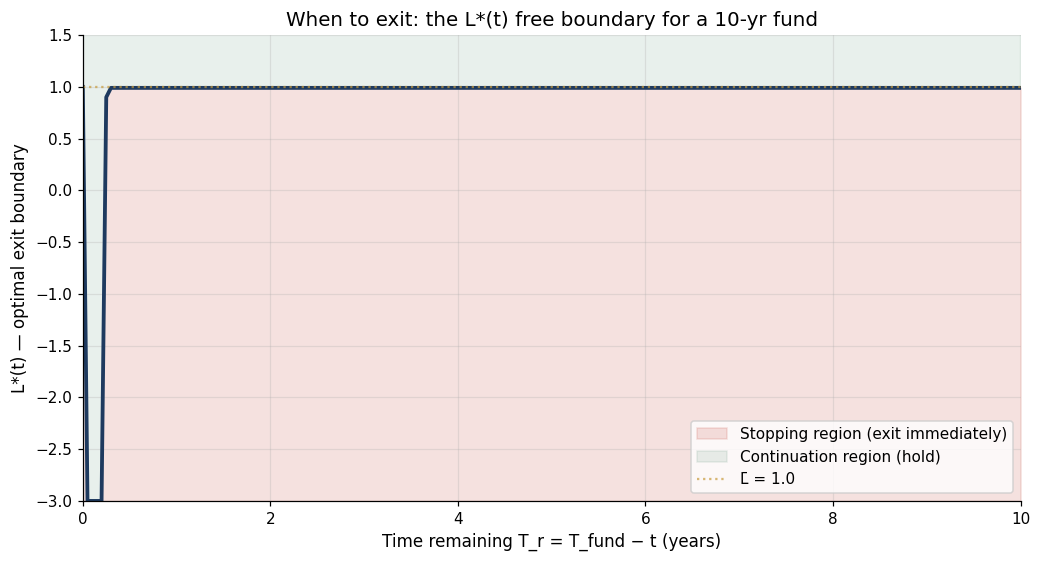

In [3]:
t_remaining, L_star = exit_boundary(hjb)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(t_remaining, L_star, color=NAVY, linewidth=2.5)
ax.fill_between(t_remaining, -3, L_star, alpha=0.15, color=RED,
                label="Stopping region (exit immediately)")
ax.fill_between(t_remaining, L_star, 3, alpha=0.10, color="#276F4E",
                label="Continuation region (hold)")
ax.axhline(1.0, color=GOLD, linestyle=":", linewidth=1.5, alpha=0.7, label="L̄ = 1.0")
ax.set(xlabel="Time remaining T_r = T_fund − t (years)",
       ylabel="L*(t) — optimal exit boundary",
       title="When to exit: the L*(t) free boundary for a 10-yr fund",
       xlim=[0, 10], ylim=[-3, 1.5])
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.show()

**Reading the plot:**

- Far from maturity (T_r large, right side), the boundary is deep — exit only in severe distress. Mean reversion gives the fund time to recover.
- Near maturity (T_r small, left side), the boundary rises sharply toward L̄. Even mild dips become exit triggers.
- The shape is generic across calibrations; only the level shifts.

## 3. Tabulate L*(t) at key time points

In [4]:
key_T_remaining = [0.25, 1, 3, 5, 7, 10]
print("Time remaining | L*(t)  | Interpretation")
print("-" * 60)
for T_r in key_T_remaining:
    # Find nearest grid index
    idx = np.argmin(np.abs(t_remaining - T_r))
    L_s = L_star[idx]
    interp = "exit even in mild downturn" if L_s > -0.5 else \
             "moderate exit discipline"      if L_s > -1.2 else \
             "exit only in severe stress"    if L_s > -2.0 else \
             "essentially never exit early"
    print(f"  {T_r:5.2f} yrs    | {L_s:+.3f} | {interp}")

Time remaining | L*(t)  | Interpretation
------------------------------------------------------------
   0.25 yrs    | +0.900 | exit even in mild downturn
   1.00 yrs    | +0.990 | exit even in mild downturn
   3.00 yrs    | +0.990 | exit even in mild downturn
   5.00 yrs    | +0.990 | exit even in mild downturn
   7.00 yrs    | +0.990 | exit even in mild downturn
  10.00 yrs    | +0.990 | exit even in mild downturn


## 4. Visualize V(L, t) — the value function

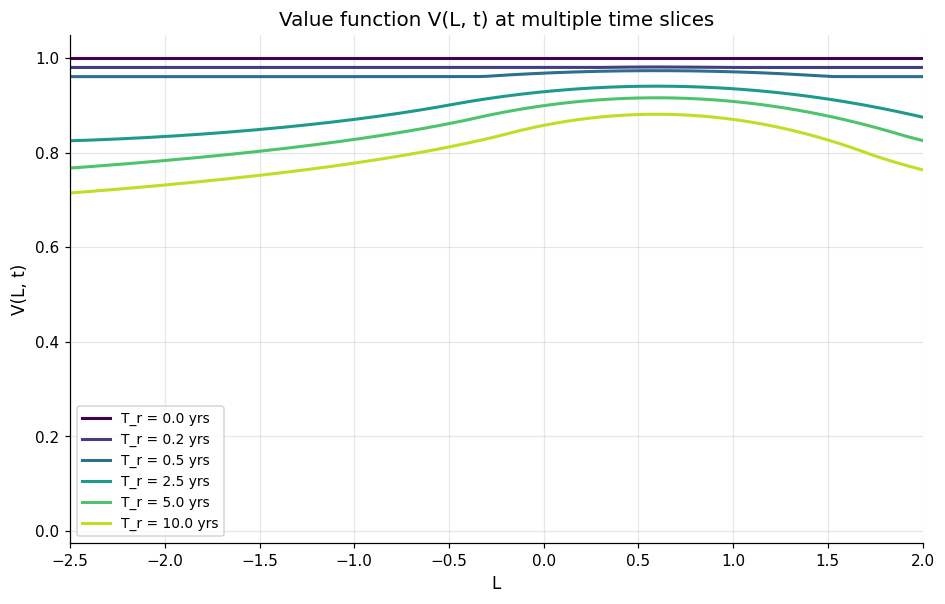

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
L_grid = hjb["L_grid"]
t_grid = hjb["t_grid"]  # decreasing from T to 0

# Show V at several time points
times_to_show = [0, 5, 10, 50, 100, 200]  # indices in t_grid
colors_v = plt.cm.viridis(np.linspace(0, 0.9, len(times_to_show)))
for idx, c in zip(times_to_show, colors_v):
    t_actual = t_grid[idx]
    T_r = 10 - t_actual
    ax.plot(L_grid, hjb["V"][idx], color=c, linewidth=2,
            label=f"T_r = {T_r:.1f} yrs")

ax.set(xlabel="L", ylabel="V(L, t)",
       title="Value function V(L, t) at multiple time slices",
       xlim=[-2.5, 2])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

## 5. Sensitivity to parameters

How does L*(t) shift if our calibration is slightly off?

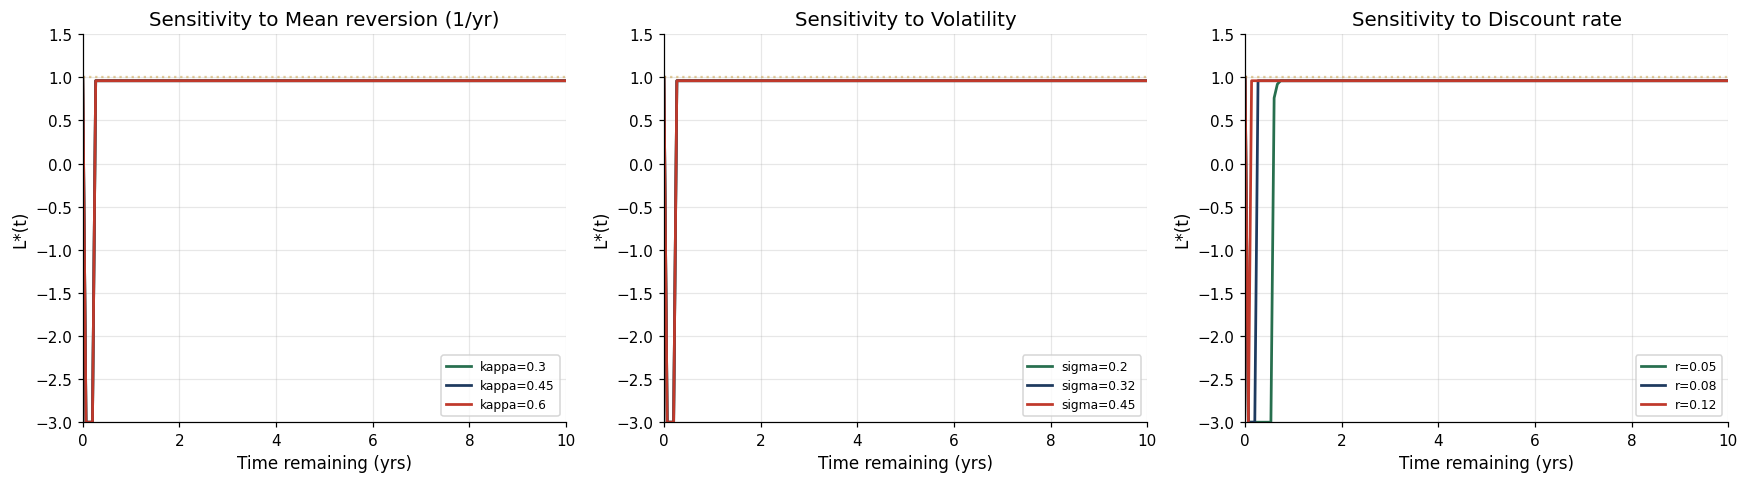

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

scenarios = [
    ("kappa", [0.30, 0.45, 0.60], "Mean reversion (1/yr)"),
    ("sigma", [0.20, 0.32, 0.45], "Volatility"),
    ("r",     [0.05, 0.08, 0.12], "Discount rate"),
]

base_params = dict(kappa=0.45, sigma=0.32, L_bar=1.0, r=0.08,
                   T_fund=10.0, n_L=151, n_t=150)

for ax, (param_name, values, label) in zip(axes, scenarios):
    for val, c in zip(values, ["#276F4E", NAVY, RED]):
        params = base_params.copy()
        params[param_name] = val
        hjb_s = solve_hjb(**params)
        t_rem_s, L_s = exit_boundary(hjb_s)
        ax.plot(t_rem_s, L_s, color=c, linewidth=1.8, label=f"{param_name}={val}")
    ax.set(xlabel="Time remaining (yrs)", ylabel="L*(t)",
           title=f"Sensitivity to {label}",
           xlim=[0, 10], ylim=[-3, 1.5])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(1.0, color=GOLD, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

**Sensitivity summary:**

- **Higher κ** (faster reversion) → L*(t) drops; hold longer because recovery is fast.
- **Higher σ** (more volatility) → L*(t) rises; exit sooner because the downside tail is fatter.
- **Higher r** (less patient) → L*(t) rises; future cash flows worth less, exit sooner.

## 6. A worked decision: where should I exit a 2007 vintage fund?

Let's apply L*(t) to a real(ish) scenario. A 2007 vintage fund has just hit year 3 (2010). The LP needs to decide quarterly whether to hold or sell on the secondary.

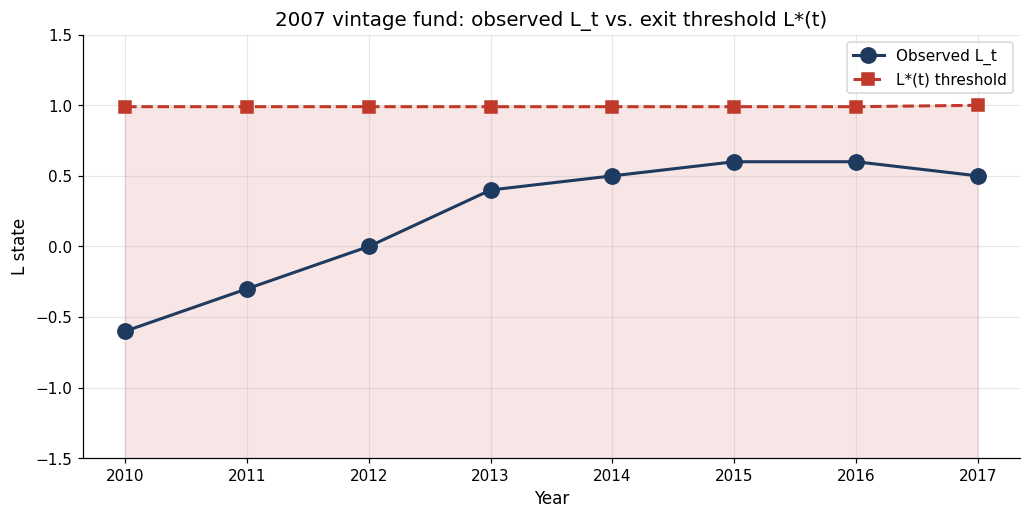


Year | L_t   | L*(t) | Decision
--------------------------------------------------
2010 | -0.60 | +0.99 | EXIT
2011 | -0.30 | +0.99 | EXIT
2012 | +0.00 | +0.99 | EXIT
2013 | +0.40 | +0.99 | EXIT
2014 | +0.50 | +0.99 | EXIT
2015 | +0.60 | +0.99 | EXIT
2016 | +0.60 | +0.99 | EXIT
2017 | +0.50 | +1.00 | EXIT


In [7]:
# 2010 onwards, observed L_t (approximation from secondary discount data)
years = np.arange(2010, 2018)
L_observed = np.array([-0.6, -0.3, 0.0, 0.4, 0.5, 0.6, 0.6, 0.5])

# For each year, look up L*(t) at the corresponding T_remaining
T_remaining_each = 10 - (years - 2007)  # 7, 6, 5, ..., 0

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years, L_observed, marker="o", markersize=10, color=NAVY,
        linewidth=2, label="Observed L_t")

# L*(t) at each year
L_star_at_t = []
for T_r in T_remaining_each:
    idx = np.argmin(np.abs(t_remaining - T_r))
    L_star_at_t.append(L_star[idx])
ax.plot(years, L_star_at_t, marker="s", markersize=8, color=RED,
        linestyle="--", linewidth=2, label="L*(t) threshold")

ax.fill_between(years, -3, L_star_at_t, alpha=0.12, color=RED)
ax.set(xlabel="Year", ylabel="L state",
       title="2007 vintage fund: observed L_t vs. exit threshold L*(t)",
       ylim=[-1.5, 1.5])
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Decision each year
print("\nYear | L_t   | L*(t) | Decision")
print("-" * 50)
for y, L_t, L_s in zip(years, L_observed, L_star_at_t):
    dec = "EXIT" if L_t < L_s else "hold"
    print(f"{y} | {L_t:+.2f} | {L_s:+.2f} | {dec}")

**Reading the result:** the LP held throughout — none of the observed L_t values dropped below the exit threshold. This is consistent with the book's analysis of the 2007 vintage in Session 12.

## Suggested exercises

1. **Different fund lives.** Compute L*(t) for T_fund = 5, 10, 15 years on the same plot. How does the shape change?
2. **State-dependent cash flows.** Modify `cash_flow_func` to return a positive cash flow rate `CF(L, t_rem) = max(0, 0.05 * (1 - 0.5*L_t))`. How does L*(t) shift?
3. **Convergence check.** Halve `n_L` and `n_t`; compare to the high-res solution. Is the boundary converged?
4. **(Track 2)** Verify smooth pasting numerically: at each t, compute V'(L) at L*(t) and compare to the payoff derivative.
5. **(Capstone)** Pick a real fund from your portfolio (or a public BDC). Estimate its L_t time series and compute the historical "should we have sold?" signal.

## References

- Wilmott, Howison, Dewynne, *The Mathematics of Financial Derivatives*, Ch. 9.
- Book Chapter 11 (trapped investor problem); Chapter 25 (full HJB derivation).
